In [38]:
print("Shri Ganeshay namh")
print("Ganapati Bappaa Morya")

Shri Ganeshay namh
Ganapati Bappaa Morya


In [39]:
import torch
print("PyTorch Version:", torch.__version__)
print("Is GPU available?:", torch.cuda.is_available())

PyTorch Version: 2.12.1+cpu
Is GPU available?: False


In [40]:
import os

TRAIN_DIR = "Data/train"
VAL_DIR = "Data/validation"

print("------> Training Data Count <------")
for cell_type in os.listdir(TRAIN_DIR):
    folder_path = os.path.join(TRAIN_DIR,cell_type)
    if os.path.isdir(folder_path):
        image_num = len(os.listdir(folder_path))
        print(f"{cell_type} : {image_num} images")
 

------> Training Data Count <------
EOSINOPHIL : 2497 images
LYMPHOCYTE : 2483 images
MONOCYTE : 2478 images
NEUTROPHIL : 2499 images


In [42]:
import matplotlib.pyplot as plt

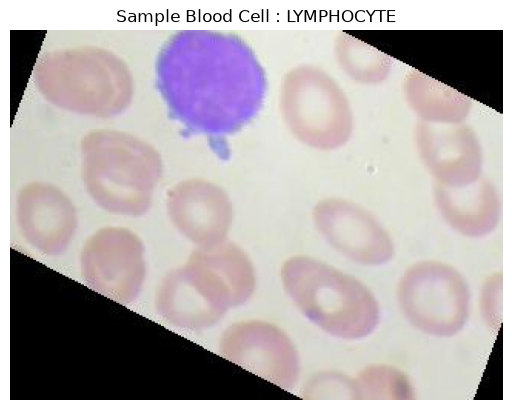

image size : (320, 240)


In [43]:
from PIL import Image

sample_imgpath = "Data/train/LYMPHOCYTE/_0_331.jpeg"

try:
    img = Image.open(sample_imgpath)
    plt.imshow(img)
    
    plt.title("Sample Blood Cell : LYMPHOCYTE")
    
    plt.axis("off")
    plt.show()

    print(f"image size : {img.size}")

except FileNotFoundError:
    print("File not found please check path")    




In [44]:
import numpy as np
import pandas as pd 
import torch.nn as nn


In [45]:
class BloodCellClassifier(nn.Module):
    def __init__(self):
        super(BloodCellClassifier, self).__init__()

        self.con1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.rel1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2 , stride=2)


        self.con2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.rel2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.fc1 = nn.Linear(32*56*56, 128)
        self.rel3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 4)

    def forward(self , x):
        x = self.pool1(self.rel1(self.con1(x)))
        x = self.pool2(self.rel2(self.con2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.rel3(x)
        x = self.fc2(x)

        return x

In [46]:
model = BloodCellClassifier()


In [47]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [48]:
criterion = nn.CrossEntropyLoss()

In [49]:
print(model)

BloodCellClassifier(
  (con1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rel1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (con2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rel2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (rel3): ReLU()
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [50]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


train_dataset = ImageFolder(root="data/train", transform=data_transform)
val_dataset = ImageFolder(root="data/val", transform=data_transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)



In [52]:
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0



    for batch_idx, (images,labels) in enumerate(train_loader):

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        
        if batch_idx % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx}/{len(train_loader)}] | Loss: {loss.item():.4f}")
        
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"=== Epoch {epoch+1} Complete | Avg Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}% ===")



Epoch [1/3] | Batch [0/312] | Loss: 1.3755
Epoch [1/3] | Batch [10/312] | Loss: 1.3815
Epoch [1/3] | Batch [20/312] | Loss: 1.3835
Epoch [1/3] | Batch [30/312] | Loss: 1.4323
Epoch [1/3] | Batch [40/312] | Loss: 1.3478
Epoch [1/3] | Batch [50/312] | Loss: 1.4245
Epoch [1/3] | Batch [60/312] | Loss: 1.3905
Epoch [1/3] | Batch [70/312] | Loss: 1.3670
Epoch [1/3] | Batch [80/312] | Loss: 1.3561
Epoch [1/3] | Batch [90/312] | Loss: 1.3648
Epoch [1/3] | Batch [100/312] | Loss: 1.3373
Epoch [1/3] | Batch [110/312] | Loss: 1.3389
Epoch [1/3] | Batch [120/312] | Loss: 1.3683
Epoch [1/3] | Batch [130/312] | Loss: 1.3339
Epoch [1/3] | Batch [140/312] | Loss: 1.2829
Epoch [1/3] | Batch [150/312] | Loss: 1.3903
Epoch [1/3] | Batch [160/312] | Loss: 1.3329
Epoch [1/3] | Batch [170/312] | Loss: 1.2834
Epoch [1/3] | Batch [180/312] | Loss: 1.2732
Epoch [1/3] | Batch [190/312] | Loss: 1.3198
Epoch [1/3] | Batch [200/312] | Loss: 1.3250
Epoch [1/3] | Batch [210/312] | Loss: 1.2138
Epoch [1/3] | Batch [

In [53]:
torch.save(model.state_dict(), "blood_cell_model.pth")